# Interacting particles in a Box

## Schrödinger Equation for Two Particles in a Box with Infinite Potential:

The Schrödinger equation for a system of two interacting particles confined to a one-dimensional box with infinitely high sides is given by:

$$
-\frac{\hbar^2}{2m} \left( \frac{\partial^2 \psi}{\partial x_1^2} + \frac{\partial^2 \psi}{\partial x_2^2} \right) + V(x_1, x_2) \psi = E \psi \tag{1}
$$

Here, $m$ is the particles' mass, $\hbar$ is the reduced Planck constant, $x_1$ and $x_2$ are the positions of the two particles, $V(x_1, x_2)$ is the interaction potential, $E$ is the total energy, and $\psi$ is the wave function.

### Part 1. Build intuition.

To solve this equation numerically, we need to discretize the Laplacian operator. One can show that the finite difference approximation to the second derivative is:

$$
\frac{\partial^2 \psi}{\partial x_i^2} \approx \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{(\Delta x)^2}
$$

Here, $\Delta x$ is the spatial step size.

Substituting the discretized Laplacian into the 1 dimensional Schrödinger equation for particle in box, we get a set of difference equations:

$$
    -\frac{\hbar^2}{2m} \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\Delta x^2} + V(x_i) \psi_i = E \psi_i  \tag{2}
$$

This equation holds for each grid point $x_i$ within the box.

Equation (2) can be represented in terms of matrices as

$$
-\frac{\hbar^2}{2m}
\begin{bmatrix}
-2 & 1 & 0 & \ldots & 0 \\
1 & -2 & 1 & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & \ldots & 1 & -2 & 1 \\
0 & \ldots & 0 & 1 & -2 \\
\end{bmatrix} \begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_n
\end{bmatrix} + \begin{bmatrix}
V(x_1) & 0 & \ldots & 0 \\
0 & V(x_2) & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & \ldots & 0 & V(x_n)
\end{bmatrix} \begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_n
\end{bmatrix}= E \begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_n
\end{bmatrix}
$$

Thus, Hamiltonian operator can be rewritten as

$$
\hat{H} = \hat{T} + \hat{U} =
-\frac{\hbar^2}{2m}
\begin{bmatrix}
-2 & 1 & 0 & \ldots & 0 \\
1 & -2 & 1 & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & \ldots & 1 & -2 & 1 \\
0 & \ldots & 0 & 1 & -2 \\
\end{bmatrix} + \begin{bmatrix}
V(x_1) & 0 & \ldots & 0 \\
0 & V(x_2) & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & \ldots & 0 & V(x_n)
\end{bmatrix} = -\frac{\hbar^2}{2m} \cdot \mathbf{D}_{xx}+ \mathbf{V}_x
$$

Here we defined

$$
\mathbf{D}_{xx} = \begin{bmatrix}
-2 & 1 & 0 & \ldots & 0 \\
1 & -2 & 1 & \ldots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & \ldots & 1 & -2 & 1 \\
0 & \ldots & 0 & 1 & -2 \\
\end{bmatrix}
$$

### Part 2. Algorithm

Because our initial problem (1) is two-dimensional, we need to use the discrete version of 2d Laplacian. Because it's derivation is beyond the scope of the course, here we show you only the final formula. However, reader can learn more about discrete 2d laplacian [here](https://en.wikipedia.org/wiki/Discrete_Laplace_operator) and [here](https://en.wikipedia.org/wiki/Kronecker_sum_of_discrete_Laplacians).

$$
\mathbf{L}=\mathbf{D}_{\mathrm{xx}} \oplus \mathbf{D}_{\mathrm{yy}}=\mathbf{D}_{\mathrm{xx}} \otimes \mathbf{I}+\mathbf{I} \otimes \mathbf{D}_{\mathrm{yy}} \tag{3}
$$

Symbol $\otimes$ denotes [Kronecker product](https://en.wikipedia.org/wiki/Kronecker_product)

Considering the equivalence of electrons, we can write the kinetic energy operator as

$$
\hat{T}=-\frac{\hbar^2}{2m}  \mathbf{D}_{\mathrm{xx}} \oplus \mathbf{D}_{\mathrm{yy}}
$$

The potential energy operator is much easier to define. The interaction between electrons can be written:

$$
V(x, x') = \frac{e^2}{4\pi\epsilon_0} \cdot \frac{1}{|x-x'|}
$$

Here:

- $e$ is the elementary charge (approximately $1.602 \times 10^{-19}$ Coulombs),
- $\epsilon_0$ is the permittivity of vacuum $(8.854 \times 10^{-12} \, \text{C}^2/\text{N}\cdot\text{m}^2$),
- $|x-x'|$ is the separation between the electrons.
- We will use _atomic units_ where $\hbar = m = \tfrac{e^2}{4\pi\epsilon_0} = 1$. This makes our notation much simpler.

To make the assignment more interesting, we introduce the interaction strength parameter, $\kappa$, such as

$$
V(x, x') = \kappa \cdot \frac{1}{|x-x'|} \tag{4}
$$

By varying the values of $\kappa$ we can control how strongly the electrons repel each other. Keep in mind, that $V(x, x')|_{x=x'} = \infty$. For the sake of numerical stability, you will need to populate matrix $V(x, x')|_{x=x'}$ with a big enough, but finite number; $10^5$ should do the job.

### Part 3. Combining everything together

To solve the problem (1) numerically one needs to define:

1. A grid: points at which values of wavefuncion has to be calculated.
2. Construct discrete operators for the 2-dimensional region where electrons are located.
   1. Kinetic energy operator, $\mathbf{L}$. See Eq. (3).
   2. Potential operator, $\mathbf{U}$. See Eq. (4).
3. Solve the general eigenvalue problem.
   $$
   \left(-\tfrac{1}{2}\mathbf{L} + \kappa \mathbf{U}\right) \mathbf{v}_k(\kappa) = E_k(\kappa) \mathbf{v}_k(\kappa)
   $$
   We will use [scipy.sparse.linalg.eigsh](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html) to determine the eigenvalues and eigenvectors.


## &#x1f469;&#x1f3fd;&#x200d;&#x1f4bb; Assignment: Complete the Below Notebook

To do this, complete the code blocks indicated by `### START YOUR CODE HERE` and `### END YOUR CODE HERE` .

The detailed steps you'll follow are:

1. Construct the discrete Laplacian operator, `T_hat(N)`. See formula (3).
1. Construct the discrete potential operator, `U_hat(N, kappa)`. This is the discrete version of formula (4).
1. Confirm that when $\kappa = 0$, the energy levels and eigenvectors are very close to what we would expect for two non-interacting particles in a box.
1. The provided plot functions will then plot your probability distribution. Play with this function and build intuition for the result.
1. Upload your notebook and confirm its correctness. The marking scheme is provided at the end of this document.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy


def T_hat(N):
    """
    Create a finite difference representation of the kinetic energy operator
    using a second order central difference scheme.

    Parameters
    ----------
    N : int
        Number of points in the grid (N x N)

    Returns
    -------
    T : scipy.sparse.csr_matrix
        Kinetic energy operator
    """

    # define a linear space from 0 to 1
    # with N points
    x = np.linspace(0, 1, N)

    ### START YOUR CODE HERE ###
    # calculate the increment between points in the 1D grid
    dx = x[1] - x[0]

    # Define a vector of ones of length N using np.ones
    diag = np.ones(N)

    # define an array containing the tridiagonal values for the k.e. operator
    # using np.array
    diags = np.array([diag, -2 * diag, diag])

    # calculate the kinetic energy operator
    # for the x direction using scipy.sparse.spdiags
    D = scipy.sparse.spdiags(diags, np.array([-1, 0, 1]), N, N) / dx**2

    ### END YOUR CODE HERE ###

    # Calculate the kinetic energy operator
    # for the 2D grid
    T = -1 / 2 * scipy.sparse.kronsum(D, D)

    return T
    ### END YOUR CODE HERE ###


def U_hat(N, kappa):
    """
    Calculate the Coulomb potential energy, 1/|x-x'|, operator on the grid.

    Parameters
    ----------
    N : int
        Number of points in the grid (N x N)
    kappa : float
        Strength of the potential

    Returns
    -------
    U : numpy.ndarray
        Potential energy operator
    """

    # create a grid size N x N
    # from 0 to 1 in both x and y directions
    x, x_prime = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N))

    ### START YOUR CODE HERE ###

    # calculate the potential energy operator
    U = kappa / (np.abs(x - x_prime))
    np.fill_diagonal(U, 1e5)
    # set the diagonal to a large number (1e5) using np.fill_diagonal


    ### END YOUR CODE HERE ###

    return U


def solve_pde(T, U):
    """
    Solve the PDE using the finite difference method.

    Parameters
    ----------
    T : scipy.sparse.csr_matrix
        Kinetic energy operator
    U : numpy.ndarray
        Potential energy operator

    Returns
    -------
    eigvals : numpy.ndarray
        Eigenvalues of the Hamiltonian
    eigvecs : numpy.ndarray
        Eigenvectors of the Hamiltonian
    """
    # build a diagonal matrix from the potential operator
    U = scipy.sparse.diags(U.flatten())

    ### START YOUR CODE HERE ###
    # construct the Hamiltonian
    H = T + U
    ### END YOUR CODE HERE ###

    # solve the equation
    eigvals, eigvecs = scipy.sparse.linalg.eigsh(H, k=4, which="SM")

    return eigvals, eigvecs


def plot_prob(eigvals, eigvecs):
    """
    Plot the probability of the states.

    Parameters
    ----------
    eigvals : numpy.ndarray
        Eigenvalues of the Hamiltonian
    eigvecs : numpy.ndarray
        Eigenvectors of the Hamiltonian

    Returns
    -------
    None
    """
    N = np.sqrt(eigvecs.shape[0]).astype(int)

    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    for i in range(2):
        for j in range(2):
            k = 2 * i + j

            wvfn = eigvecs[:, k].reshape(N, N)
            e = eigvals[k]
            axs[i, j].contourf(wvfn**2)
            axs[i, j].set_title(
                f"Probability of {k}th state with energy {np.round(e, 2)}", fontsize=7
            )
    plt.show()


/tmp/ipykernel_6046/2310785161.py:75: RuntimeWarning: invalid value encountered in divide
  U = kappa / (np.abs(x - x_prime))


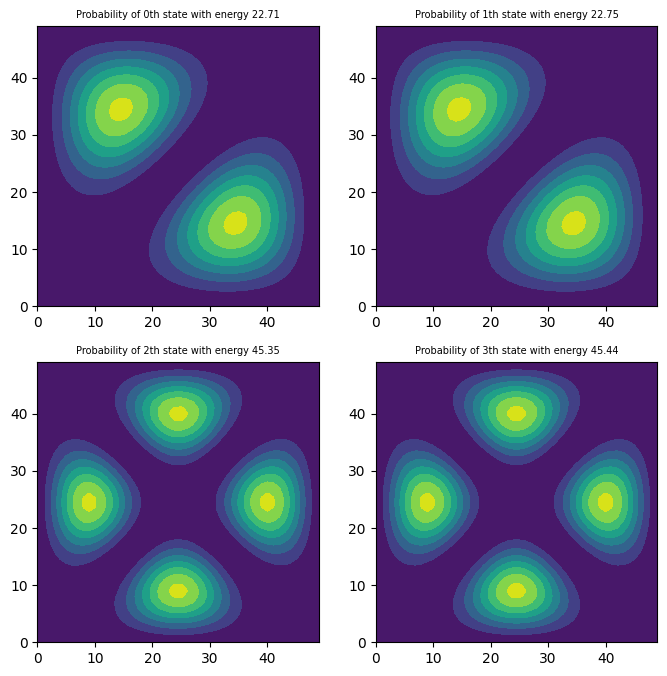

In [ ]:
T = T_hat(50)
U = U_hat(50, 0)

eigvals, eigvecs = solve_pde(T, U)
plot_prob(eigvals, eigvecs)

/tmp/ipykernel_6046/2310785161.py:75: RuntimeWarning: divide by zero encountered in divide
  U = kappa / (np.abs(x - x_prime))


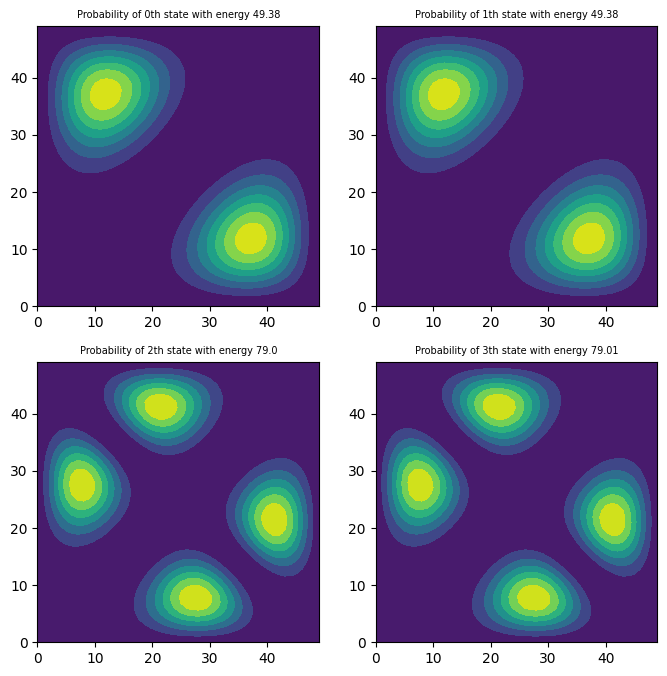

In [ ]:
T = T_hat(50)
U = U_hat(50, 10)

eigvals, eigvecs = solve_pde(T, U)
plot_prob(eigvals, eigvecs)

/tmp/ipykernel_6046/2310785161.py:75: RuntimeWarning: divide by zero encountered in divide
  U = kappa / (np.abs(x - x_prime))


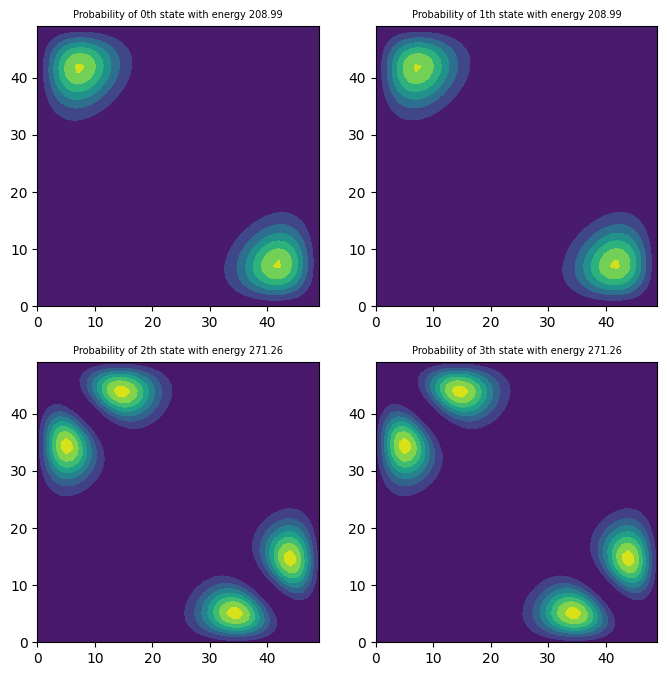

In [ ]:
T = T_hat(50)
U = U_hat(50,100)

eigvals, eigvecs = solve_pde(T, U)
plot_prob(eigvals, eigvecs)

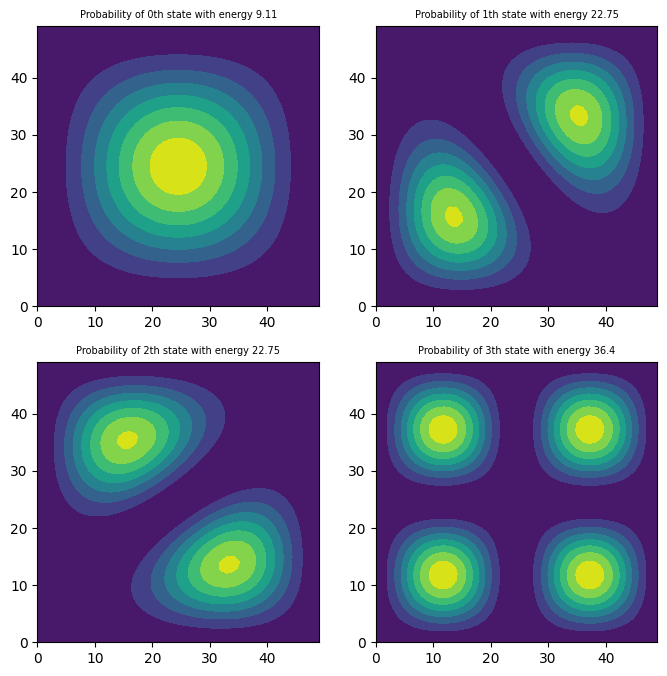

In [ ]:
T = T_hat(50)
U = np.zeros((50, 50))

eigvals, eigvecs = solve_pde(T, U)
plot_prob(eigvals, eigvecs)

### &#x1f914; Thought-Provoking Questions

- What happens when the potential $\kappa \rightarrow \infty$? Does this make sense?
- When the probability distribution function is very strongly peaked at a particular point, this corresponds to the classical limit. Explain why this is the case, and why the limit as $\kappa \rightarrow \infty$ is the classical limit.
- Explain why the ground state becomes almost degenerate with the first excited state when $\kappa$ is very large.
- While we used the "traditional" inverse-distance Coulomb potential in this exercise, in reality the "Coulomb repulsion" changes depending on the dimensionality of the system. The exact formula is below. Do the results change, qualitatively, when you use the correct formula for the 1-dimensional Coulomb repulsion?
  $$
  V_{\text{Coulomb}} =
  \begin{cases}
  \frac{-e^2}{2 \epsilon_0}|x-x'| & \text{for 1D} \\
  \frac{-e^2}{2 \pi \epsilon_0 \ln{|x-x'|}} & \text{for 2D} \\
  \frac{e^2}{4 \pi \epsilon_0 |x-x'|} & \text{for 3D} \\
  \frac{e^2 \Gamma(d/2)}{2(d-2) \pi^{\frac{d}{2}} \epsilon_0} \frac{1}{|x-x'|^{(d-2)}} & \text{for dD}
  \end{cases}
  $$


## &#x2696;&#xfe0f; Marking Scheme

&#x2611;&#xfe0f; Successful completion of the notebook, together with the ability to discuss your strategy, earns an **S**.

&#x1f4b0; For an **S+**,

- answer all of the thought-provoking questions.
  Add markdown cells and/or code to complete these tasks. You can add images of hand-written answers to the markdown cells if you prefer, but write neatly.


## &#x1f4da; References

- [Widget for 2 interacting particles in a 1-dimensional box](https://physics.weber.edu/schroeder/software/EntanglementInBox.html)


### &#x1f914; Thought-Provoking Questions - **Answers**

- What happens when the potential $\kappa \rightarrow \infty$? Does this make sense?

When $\kappa \rightarrow \infty$, the electron-electron repulsion becomes infinite, completely dominating the Hamiltonian. The potential energy term $U = \kappa / |x_1 - x_2|$ far overpowers the kinetic energy of both electrons, which means the electrons are repelled to opposite ends of the box: one pinned near $x_1 = 0$ and the other near $x_2 = L$.

This is analogous to squeezing the effective space each electron can occupy down to a single point at either wall, so $\Delta x \rightarrow 0$ for each electron. By Heisenberg's uncertainty principle:

$$\Delta x,\, \Delta p \geq \frac{\hbar}{2}$$ for both electrons.

as $\Delta x \rightarrow 0$, we require $\Delta p \rightarrow \infty$. This means the kinetic energy actually diverges too, but the infinite potential energy still dominates, keeping the electrons localized at opposite ends regardless.

This makes physical sense: infinite repulsion forces the two electrons as far apart as possible. The certainty we gain in position comes at the cost of complete uncertainty in momentum, but the overwhelming repulsion energy $U \rightarrow \infty$ locks them in place anyway.

- When the probability distribution function is very strongly peaked at a particular point, this corresponds to the classical limit. Explain why this is the case, and why the limit as $\kappa \rightarrow \infty$ is the classical limit.

A sharply peaked probability distribution corresponds to the classical limit because it means we know the positions of the electrons with near certainty. Similar to how classical mechanics assigns exact coordinates to particles, so a delta-like $|\psi(x_1, x_2)|^2$ mimics this behavior.

As $\kappa \rightarrow \infty$, the potential energy $U = \kappa / |x_1 - x_2|$ dominates the Hamiltonian so overwhelmingly that the kinetic energy term $-\frac{\hbar^2}{2m}\nabla^2$ becomes negligible; effectively rendering $\hbar \approx 0$ relative to the energy scale set by $\kappa$. This suppression of the kinetic term is what drives the classical limit, since $\hbar$ is responsible for quantization. From the Heisenberg uncertainty principle:
$$\Delta x\ \Delta p \geq \frac{\hbar}{2}\approx 0$$
if $\hbar \approx 0$ relative to the dominant energy scale, the lower bound on $\Delta x$ collapses, allowing position to become sharply defined. The probability distribution peaks strongly at $x_1 \approx 0,, x_2 \approx L$, which is exactly the classical picture of two repelling charges pinned at opposite ends of the box.

**An interesting piece of intuition**: when $\kappa$ is very large, the position of each electron becomes near-certain. This is analogous to the electrons effectively 'measuring' one another through their strong interaction, forcing the system into a near-classical, definite-position state. **Reminiscent of wavefunction collapse!** though the system remains a superposition of both peaked configurations.

It is worth noting that attributing 'measurement' to mindless particles is **philosophically striking and has me at awe**, yet the **math demands it**. This made me realize that any sufficiently strong interaction between two particles produces the same formal consequence of measurement, regardless of intent or consciousness.

- Explain why the ground state becomes almost degenerate with the first excited state when $\kappa$ is very large.

When $\kappa$ is very large, $\hat{U} \gg \hat{T}$, so the total energy of the system is almost entirely determined by the potential energy. Both the ground state and first excited state have electrons localized at opposite ends of the box; meaning their spatial configurations look nearly identical and contribute almost the same potential energy.

The only thing that distinguishes $E_0$ from $E_1$ is the small kinetic energy contribution $\hat{T}$, which is negligible when $\kappa$ is very large. Since:

$\langle \hat{H} \rangle = \langle \hat{T} \rangle + \langle \hat{U} \rangle \approx \langle \hat{U} \rangle $

both states are dominated by the same $\langle \hat{U} \rangle$, so $E_1 - E_0 \approx 0$, and the states become practically degenerate.
- While we used the "traditional" inverse-distance Coulomb potential in this exercise, in reality the "Coulomb repulsion" changes depending on the dimensionality of the system. The exact formula is below. Do the results change, qualitatively, when you use the correct formula for the 1-dimensional Coulomb repulsion?
  $$
  V_{\text{Coulomb}} =
  \begin{cases}
  \frac{-e^2}{2 \epsilon_0}|x-x'| & \text{for 1D} \\
  \frac{-e^2}{2 \pi \epsilon_0 \ln{|x-x'|}} & \text{for 2D} \\
  \frac{e^2}{4 \pi \epsilon_0 |x-x'|} & \text{for 3D} \\
  \frac{e^2 \Gamma(d/2)}{2(d-2) \pi^{\frac{d}{2}} \epsilon_0} \frac{1}{|x-x'|^{(d-2)}} & \text{for dD}
  \end{cases}
  $$

Yes, the results change qualitatively. The traditional $\kappa/|x-x'|$ potential diverges as the electrons approach each other and vanishes at large separation, pushing electrons to opposite ends of the box. The 1D Coulomb potential behaves oppositely. It is zero at $x = x'$ and grows linearly with separation, meaning large distances are penalized. This would pull the probability distribution toward configurations where the electrons are close together rather than apart, producing qualitatively opposite behavior to what we observed in this notebook.